In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from src.cnn.scratch_layers_cnn import MaxPooling2D, Flatten, LocallyConnected2D
from src.cnn.keras_layers import KerasLocallyConnected2D
from src.cnn.keras_models import build_baseline_cnn, build_local_cnn
from src.common.dense import Dense
from src.cnn.weight_loader_cnn import build_scratch_from_keras_model
from src.common.image_utils import load_image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from pathlib import Path
import json
import nltk


from src.common.image_utils import load_image, load_images, list_image_paths_by_class
from src.rnn_lstm.caption_preprocess import clean_caption, build_vocabulary, preprocess_captions
from src.rnn_lstm.scratch_decoder import build_decoder_model
from src.rnn_lstm.inference_utils import ScratchDecoderInference, evaluate_model, evaluate_model_keras

Jumlah gambar: 8091
(150, 150, 3)
0.0 1.0


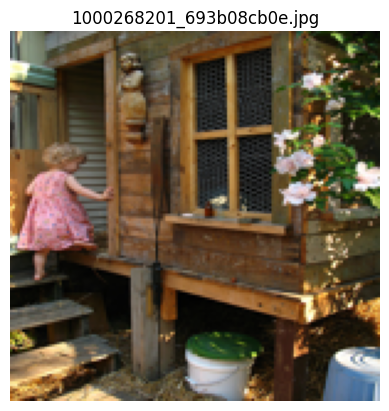

In [5]:
IMAGE_DIR = '../../data/raw/flickr8k'
image_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.jpeg', '.png'))]
total_images = len(image_files)
print(f"Jumlah gambar: {total_images}")

img = load_image(Path(IMAGE_DIR) / image_files[0], target_size=(150, 150))

print(img.shape)
print(img.min(), img.max())

plt.imshow(img)
plt.title(image_files[0])
plt.axis("off")
plt.show()

# Bagian 1

In [6]:
OUTPUT_DIR = '../../results/rnn_lstm'
encoder_model = InceptionV3(weights='imagenet', include_top=False, pooling='avg')

encoder_model.trainable = False

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [13]:
IMAGE_LOAD_BATCH_SIZE = 64

for i in range(0, total_images, IMAGE_LOAD_BATCH_SIZE):
    batch_files = image_files[i : i + IMAGE_LOAD_BATCH_SIZE]
    batch_paths = [os.path.join(IMAGE_DIR, f) for f in batch_files]

    batch_images = load_images(batch_paths, target_size=(299, 299))

    # inceptionv3 input range: [-1, 1]
    features = encoder_model.predict(batch_images, verbose=0)

    for j, file_name in enumerate(batch_files):
        base_name = os.path.splitext(file_name)[0]
        save_path = os.path.join(OUTPUT_DIR, f"{base_name}.npy")

        np.save(save_path, features[j])

    print(f"Processed {min(i + IMAGE_LOAD_BATCH_SIZE, total_images)} / {total_images} images")

print("Ekstraksi fitur selesai")

Processed 64 / 8091 images
Processed 128 / 8091 images
Processed 192 / 8091 images
Processed 256 / 8091 images
Processed 320 / 8091 images
Processed 384 / 8091 images
Processed 448 / 8091 images
Processed 512 / 8091 images
Processed 576 / 8091 images
Processed 640 / 8091 images
Processed 704 / 8091 images
Processed 768 / 8091 images
Processed 832 / 8091 images
Processed 896 / 8091 images
Processed 960 / 8091 images
Processed 1024 / 8091 images
Processed 1088 / 8091 images
Processed 1152 / 8091 images
Processed 1216 / 8091 images
Processed 1280 / 8091 images
Processed 1344 / 8091 images
Processed 1408 / 8091 images
Processed 1472 / 8091 images
Processed 1536 / 8091 images
Processed 1600 / 8091 images
Processed 1664 / 8091 images
Processed 1728 / 8091 images
Processed 1792 / 8091 images
Processed 1856 / 8091 images
Processed 1920 / 8091 images
Processed 1984 / 8091 images
Processed 2048 / 8091 images
Processed 2112 / 8091 images
Processed 2176 / 8091 images
Processed 2240 / 8091 images
P

# Bagian 2

In [7]:
CAPTIONS_FILE = "../../data/captions.txt"
FEATURES_DIR = "../../results/rnn_lstm"
OUTPUT_DIR = "../../models/rnn_lstm"
VOCAB_PATH = "../../models/rnn_lstm/vocab.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)

## sanitize caption

In [99]:
print("Membersihkan captions")
raw_captions_dict = {}

with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()

    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue

        parts = line.split(',', 1)
        if len(parts) == 2:
            img_filename, caption = parts

            img_id = os.path.splitext(img_filename)[0]

            if img_id not in raw_captions_dict:
                raw_captions_dict[img_id] = []

            cleaned = clean_caption(caption)
            raw_captions_dict[img_id].append(cleaned)

all_captions = [cap for caps in raw_captions_dict.values() for cap in caps]
print(f'Jumlah captions: {len(all_captions)}')
for i in range(3):
    print(i+1, all_captions[i])
print("...")


Membersihkan captions
Jumlah captions: 40455
1 <start> a child in a pink dress is climbing up a set of stairs in an entry way <end>
2 <start> a girl going into a wooden building <end>
3 <start> a little girl climbing into a wooden playhouse <end>
...


## build vocab

In [ ]:
vocab = build_vocabulary(all_captions, vocab_threshold=5)
vocab_size = len(vocab)

with open(VOCAB_PATH, 'w') as f:
    json.dump(vocab, f)
print(f"Jumlah tipe token: {vocab_size}")



Jumlah tipe token: 2988


In [28]:
# count maksimum sequence length untuk padding
max_seq_len = max(len(cap.split()) for cap in all_captions)
print(f"Panjang maksimum caption (max_seq_len): {max_seq_len}")

image_ids, X_caption, y_caption = preprocess_captions(raw_captions_dict, vocab, max_seq_len)

Panjang maksimum caption (max_seq_len): 37


In [50]:

X_cnn = []
missing_count = 0

for img_id in image_ids:
    feature_path = os.path.join(FEATURES_DIR, f"{img_id}.npy")
    if os.path.exists(feature_path):
        feature = np.load(feature_path)
        X_cnn.append(feature)
    else:
        # fallback
        X_cnn.append(np.zeros(2048))
        missing_count += 1

if missing_count > 0:
    print(f"{missing_count} fitur CNN tidak ditemukan, falling back")

X_cnn = np.array(X_cnn)

In [32]:
print(f"Bentuk data latih:")
print(f" - X_cnn: {X_cnn.shape}")
print(f" - X_caption: {X_caption.shape}")
print(f" - y_caption: {y_caption.shape}")

Bentuk data latih:
 - X_cnn: (40455, 2048)
 - X_caption: (40455, 36)
 - y_caption: (40455, 37)


# bagian 3

In [36]:
EMBED_DIM = 256
VARIATIONS = {
    "num_layers": [1, 2, 3],
    "hidden_size": [128, 512]
}

In [37]:
for rnn_type in ["RNN", "LSTM"]:
    for layers in VARIATIONS["num_layers"]:
        for hidden in VARIATIONS["hidden_size"]:
            print(f"\n--- Training {rnn_type} | Layers: {layers} | Hidden: {hidden} ---")

            model = build_decoder_model(
                vocab_size=vocab_size,
                max_seq_len=max_seq_len,
                embed_dim=EMBED_DIM,
                rnn_type=rnn_type,
                num_layers=layers,
                hidden_size=hidden
            )

            history = model.fit(
                x=[X_cnn, X_caption],
                y=y_caption,
                batch_size=64,
                epochs=10,
                validation_split=0.2
            )

            weight_filename = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
            save_path = os.path.join(OUTPUT_DIR, weight_filename)
            model.save_weights(save_path)
            print(f"File bobot: {save_path}")


--- Training RNN | Layers: 1 | Hidden: 128 ---
Epoch 1/10
506/506 [==============================] - 37s 71ms/step - loss: 1.7561 - val_loss: 1.2489
Epoch 2/10
506/506 [==============================] - 36s 71ms/step - loss: 1.1744 - val_loss: 1.1341
Epoch 3/10
506/506 [==============================] - 36s 71ms/step - loss: 1.0784 - val_loss: 1.0691
Epoch 4/10
506/506 [==============================] - 36s 72ms/step - loss: 1.0210 - val_loss: 1.0345
Epoch 5/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9815 - val_loss: 1.0143
Epoch 6/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9518 - val_loss: 1.0004
Epoch 7/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9285 - val_loss: 0.9881
Epoch 8/10
506/506 [==============================] - 36s 71ms/step - loss: 0.9080 - val_loss: 0.9840
Epoch 9/10
506/506 [==============================] - 36s 70ms/step - loss: 0.8900 - val_loss: 0.9777
Epoch 10/10
506/506 [=============

# Bagian 4

In [39]:
with open(VOCAB_PATH, "r") as f:
    loaded_vocab = json.load(f)

loaded_vocab_size = len(loaded_vocab)
print(f'In-memory vocab size: {vocab_size}')
print(f'Loaded vocab size: {loaded_vocab_size}')
assert vocab_size == loaded_vocab_size, "vocab size tidak sama"

MAX_SEQ_LEN = 40

In-memory vocab size: 2988
Loaded vocab size: 2988


In [100]:
unique_image_ids = list(raw_captions_dict.keys())

num_unique_images = len(unique_image_ids)
val_size = int(num_unique_images * 0.2)
val_start_index = num_unique_images - val_size
val_end_index = val_start_index + 1617

eval_image_ids = unique_image_ids[val_start_index : val_end_index]

print(f"Total data image id: {len(unique_image_ids)}")
print(f"Total eval image id: {len(eval_image_ids)}")
print(f"Data evaluasi: {len(eval_image_ids)} gambar dari index {val_start_index} hingga {val_end_index}")

Total data image id: 8091
Total eval image id: 1617
Data evaluasi: 1617 gambar dari index 6473 hingga 8090


In [116]:
X_cnn_eval  = []
y_refs_eval = []

for img_id in eval_image_ids:
    feature_path = os.path.join(FEATURES_DIR, f"{img_id}.npy")
    if os.path.exists(feature_path):
        X_cnn_eval.append(np.load(feature_path))
    else:
        X_cnn_eval.append(np.zeros(2048))
    y_refs_eval.append(raw_captions_dict[img_id])

In [113]:
print(f"Panjang X_cnn_eval: {len(X_cnn_eval)}")
print(f"Panjang y_refs_eval: {len(y_refs_eval)}")
assert len(X_cnn_eval) == len(y_refs_eval), "panjang X dan y harus sama"

Panjang X_cnn_eval: 1617
Panjang y_refs_eval: 1617


In [ ]:
results = []

for rnn_type in ["RNN", "LSTM"]:
    for layers in VARIATIONS["num_layers"]:
        for hidden in VARIATIONS["hidden_size"]:
            print(f"Evaluasi {rnn_type} | Layers: {layers} | Hidden: {hidden}")

            keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, rnn_type, layers, hidden)
            weight_path = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
            load_path = os.path.join(OUTPUT_DIR, weight_path)
            keras_model.load_weights(load_path)

            scratch_model = ScratchDecoderInference(loaded_vocab, rnn_type, layers, EMBED_DIM, hidden)
            scratch_model.load_weights_from_keras(keras_model)

            bleu, meteor, exec_time, preds = evaluate_model(scratch_model, X_cnn_eval, y_refs_eval, max_length=MAX_SEQ_LEN)

            results.append({
                "Model": rnn_type,
                "Layers": layers,
                "Hidden Size": hidden,
                "Corpus BLEU-4": bleu,
                "Avg. METEOR": meteor,
                "Time": exec_time,
                "Preds": preds
            })



Evaluasi RNN | Layers: 1 | Hidden: 128
Evaluasi RNN | Layers: 1 | Hidden: 512
Evaluasi RNN | Layers: 2 | Hidden: 128
Evaluasi RNN | Layers: 2 | Hidden: 512
Evaluasi RNN | Layers: 3 | Hidden: 128
Evaluasi RNN | Layers: 3 | Hidden: 512
Evaluasi LSTM | Layers: 1 | Hidden: 128


c:\Users\rizac\sigma\ml\Tugas-Besar-ML-2\src\common\activations.py:15: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Evaluasi LSTM | Layers: 1 | Hidden: 512
Evaluasi LSTM | Layers: 2 | Hidden: 128
Evaluasi LSTM | Layers: 2 | Hidden: 512
Evaluasi LSTM | Layers: 3 | Hidden: 128
Evaluasi LSTM | Layers: 3 | Hidden: 512


In [115]:
with open(Path(FEATURES_DIR) / 'scratch_results.json', 'w') as f:
    json.dump(results, f)

In [119]:
df_results = pd.DataFrame(results)
df_results.sort_values(by="Corpus BLEU-4", ascending=False).drop(columns=['Preds'])

,Model,Layers,Hidden Size,Corpus BLEU-4,Avg. METEOR,Time
7,LSTM,1,512,0.147896,0.348671,184.040311
9,LSTM,2,512,0.139674,0.347714,308.827761
1,RNN,1,512,0.134276,0.341362,142.224885
11,LSTM,3,512,0.129956,0.332943,415.467923
5,RNN,3,512,0.124988,0.318675,202.188988
3,RNN,2,512,0.112869,0.304319,169.653029
0,RNN,1,128,0.104465,0.290098,93.647153
6,LSTM,1,128,0.095392,0.284296,107.990179
2,RNN,2,128,0.085008,0.291654,162.253253
10,LSTM,3,128,0.081341,0.285985,201.229855


In [89]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rizac\AppData\Roaming\nltk_data...


True

In [132]:
best_configs = [
    {"type": "RNN", "layers": 1, "hidden": 512},
    {"type": "LSTM", "layers": 1, "hidden": 512}
]

compare_results = []

for config in best_configs:
    rnn_type = config["type"]
    layers = config["layers"]
    hidden = config["hidden"]

    print(f"\n{rnn_type} | (Layers: {layers} | Hidden: {hidden})")

    keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, rnn_type, layers, hidden)
    weight_path = f"{rnn_type}_L{layers}_H{hidden}_weights.h5"
    load_path = os.path.join(OUTPUT_DIR, weight_path)
    keras_model.load_weights(load_path)

    bleu_keras, meteor_keras, time_keras, detailed_keras = evaluate_model_keras(
        keras_model, X_cnn_eval, y_refs_eval, vocab, model_max_seq_len=MAX_SEQ_LEN, limit_length=MAX_SEQ_LEN
    )
    compare_results.append({
        "Model": f"{rnn_type}",
        "Implementation": "Keras",
        "Corpus BLEU-4": bleu_keras,
        "Avg. METEOR": meteor_keras,
        "Time": time_keras,
        "Preds": detailed_keras,
    })


RNN | (Layers: 1 | Hidden: 512)

LSTM | (Layers: 1 | Hidden: 512)


In [ ]:
df_compare_results = pd.DataFrame(compare_results)
df_compare_results.drop(columns=['Preds'])

,Model,Implementation,Corpus BLEU-4,Avg. METEOR,Time
0,RNN,Keras,0.134276,0.341362,1224.417219
1,LSTM,Keras,0.147896,0.348671,1489.628119


In [144]:
df_best_scratch_results = df_results.sort_values(by='Corpus BLEU-4', ascending=False).drop_duplicates(subset=['Model'])
df_best_scratch_results['Implementation'] = 'Scratch'
df_best_scratch_results

,Model,Layers,Hidden Size,Corpus BLEU-4,Avg. METEOR,Time,Preds,Implementation
7,LSTM,1,512,0.147896,0.348671,184.040311,"[{'image_index': 0, 'prediction': 'a group of ...",Scratch
1,RNN,1,512,0.134276,0.341362,142.224885,"[{'image_index': 0, 'prediction': 'a group of ...",Scratch


In [146]:

merged_results_df = pd.concat([df_compare_results, df_best_scratch_results.drop(columns=['Layers', 'Hidden Size'])])
merged_results_df.sort_values(by='Corpus BLEU-4', ascending=False)

,Model,Implementation,Corpus BLEU-4,Avg. METEOR,Time,Preds
1,LSTM,Keras,0.147896,0.348671,1489.628119,"[{'image_index': 0, 'prediction': 'a group of ..."
7,LSTM,Scratch,0.147896,0.348671,184.040311,"[{'image_index': 0, 'prediction': 'a group of ..."
0,RNN,Keras,0.134276,0.341362,1224.417219,"[{'image_index': 0, 'prediction': 'a group of ..."
1,RNN,Scratch,0.134276,0.341362,142.224885,"[{'image_index': 0, 'prediction': 'a group of ..."


SKOR CORPUS BLEU-4 SAMA PERSIS (sejauh presisi desimal), tapi karena waktu scratch jauh lebih cepat, kita pilih scratch LSTM (1 layer dan 512 hidden size) sebagai model terbaik

In [149]:
length_variations = [10, 20, MAX_SEQ_LEN]
length_results = []

best_type = 'LSTM'
best_layers = 1
best_hidden = 512

for limit_len in length_variations:
    print(f"Caption max length = {limit_len}")

    keras_model = build_decoder_model(loaded_vocab_size, MAX_SEQ_LEN, EMBED_DIM, best_type, best_layers, best_hidden)
    weight_path = f"{best_type}_L{best_layers}_H{best_hidden}_weights.h5"
    load_path = os.path.join(OUTPUT_DIR, weight_path)
    keras_model.load_weights(load_path)

    scratch_model = ScratchDecoderInference(loaded_vocab, best_type, best_layers, EMBED_DIM, best_hidden)
    scratch_model.load_weights_from_keras(keras_model)

    bleu, meteor, exec_time, pred = evaluate_model(scratch_model, X_cnn_eval, y_refs_eval, max_length=limit_len)

    length_results.append({
        "Max Length": limit_len,
        "Corpus BLEU-4": bleu,
        "Avg. METEOR": meteor,
        "Time": exec_time,
        "Preds": pred,
    })


Caption max length = 10
Caption max length = 20
Caption max length = 40


In [150]:
df_lengths = pd.DataFrame(length_results)
df_lengths

,Max Length,Corpus BLEU-4,Avg. METEOR,Time,Preds
0,10,0.159629,0.340115,155.517466,"[{'image_index': 0, 'prediction': 'a group of ..."
1,20,0.148625,0.348520,159.041371,"[{'image_index': 0, 'prediction': 'a group of ..."
2,40,0.147896,0.348671,157.594217,"[{'image_index': 0, 'prediction': 'a group of ..."


In [ ]:
# df_results.to_pickle(Path(FEATURES_DIR) / 'df_results.pkl')
# df_best_scratch_results.to_pickle(Path(FEATURES_DIR) / 'df_best_scratch_results.pkl')
# df_compare_results.to_pickle(Path(FEATURES_DIR) / 'df_compare_results.pkl')
# merged_results_df.to_pickle(Path(FEATURES_DIR) / 'merged_results_df.pkl')
# df_lengths.to_pickle(Path(FEATURES_DIR) / 'df_lengths.pkl')

In [ ]:
# df_results = pd.read_pickle(Path(FEATURES_DIR) / 'df_results.pkl')
# df_best_scratch_results = pd.read_pickle(Path(FEATURES_DIR) / 'df_best_scratch_results.pkl')
# df_compare_results = pd.read_pickle(Path(FEATURES_DIR) / 'df_compare_results.pkl')
# merged_results_df = pd.read_pickle(Path(FEATURES_DIR) / 'merged_results_df.pkl')
# df_lengths = pd.read_pickle(Path(FEATURES_DIR) / 'df_lengths.pkl')

aku lupa simpen loss history training, maafkan

tpi manual aman, karena gk mau training 6 jam lagi

In [24]:
rnn_histories = {
    "RNN L1 H128": {
        "train": [1.7561, 1.1744, 1.0784, 1.0210, 0.9815,
                  0.9518, 0.9285, 0.9080, 0.8900, 0.8743],
        "val":   [1.2489, 1.1341, 1.0691, 1.0345, 1.0143,
                  1.0004, 0.9881, 0.9840, 0.9777, 0.9747]
    },

    "RNN L1 H512": {
        "train": [1.4726, 1.0709, 0.9627, 0.9002, 0.8557,
                  0.8188, 0.7871, 0.7572, 0.7311, 0.7057],
        "val":   [1.1608, 1.0384, 0.9869, 0.9679, 0.9553,
                  0.9533, 0.9551, 0.9584, 0.9632, 0.9712]
    },

    "RNN L2 H128": {
        "train": [1.7194, 1.1753, 1.0887, 1.0364, 1.0009,
                  0.9676, 0.9377, 0.9146, 0.8954, 0.8785],
        "val":   [1.2507, 1.1373, 1.0835, 1.0519, 1.0355,
                  1.0114, 1.0011, 0.9907, 0.9862, 0.9835]
    },

    "RNN L2 H512": {
        "train": [1.4731, 1.1619, 1.0682, 1.0181, 0.9755,
                  0.9386, 0.9140, 0.8931, 0.8703, 0.8497],
        "val":   [1.2158, 1.1189, 1.0752, 1.0466, 1.0240,
                  1.0103, 1.0057, 1.0110, 0.9947, 0.9983]
    },

    "RNN L3 H128": {
        "train": [1.8135, 1.2758, 1.1664, 1.0988, 1.0450,
                  1.0043, 0.9713, 0.9451, 0.9224, 0.9032],
        "val":   [1.3656, 1.2190, 1.1476, 1.0932, 1.0617,
                  1.0379, 1.0168, 1.0053, 0.9958, 0.9956]
    },

    "RNN L3 H512": {
        "train": [1.5549, 1.2400, 1.1533, 1.0886, 1.0357,
                  0.9996, 0.9631, 0.9355, 0.9124, 0.8893],
        "val":   [1.3101, 1.2024, 1.1470, 1.0960, 1.0625,
                  1.0444, 1.0267, 1.0182, 1.0071, 1.0003]
    }
}


lstm_histories = {
    "LSTM L1 H128": {
        "train": [1.8296, 1.2594, 1.1530, 1.0850, 1.0363,
                  1.0015, 0.9737, 0.9502, 0.9303, 0.9127],
        "val":   [1.3519, 1.2029, 1.1335, 1.0816, 1.0502,
                  1.0283, 1.0107, 0.9971, 0.9870, 0.9784]
    },

    "LSTM L1 H512": {
        "train": [1.5092, 1.1300, 1.0221, 0.9482, 0.8949,
                  0.8540, 0.8192, 0.7884, 0.7601, 0.7337],
        "val":   [1.2210, 1.0856, 1.0153, 0.9750, 0.9473,
                  0.9306, 0.9207, 0.9143, 0.9112, 0.9123]
    },

    "LSTM L2 H128": {
        "train": [1.9578, 1.3806, 1.2486, 1.1686, 1.1195,
                  1.0824, 1.0514, 1.0254, 1.0013, 0.9791],
        "val":   [1.5040, 1.3068, 1.2106, 1.1536, 1.1182,
                  1.0897, 1.0666, 1.0480, 1.0313, 1.0155]
    },

    "LSTM L2 H512": {
        "train": [1.5461, 1.1457, 1.0419, 0.9761, 0.9238,
                  0.8825, 0.8481, 0.8178, 0.7891, 0.7624],
        "val":   [1.2382, 1.0982, 1.0412, 0.9983, 0.9699,
                  0.9496, 0.9411, 0.9330, 0.9255, 0.9268]
    },

    "LSTM L3 H128": {
        "train": [2.0406, 1.4446, 1.3093, 1.2372, 1.1826,
                  1.1331, 1.0938, 1.0632, 1.0365, 1.0129],
        "val":   [1.5809, 1.3593, 1.2770, 1.2195, 1.1705,
                  1.1348, 1.1029, 1.0805, 1.0614, 1.0431]
    },

    "LSTM L3 H512": {
        "train": [1.5790, 1.1660, 1.0623, 0.9939, 0.9400,
                  0.8977, 0.8614, 0.8303, 0.8015, 0.7742],
        "val":   [1.2541, 1.1213, 1.0543, 1.0093, 0.9789,
                  0.9584, 0.9449, 0.9391, 0.9330, 0.9307]
    }
}

In [26]:
epochs = range(1, 11)

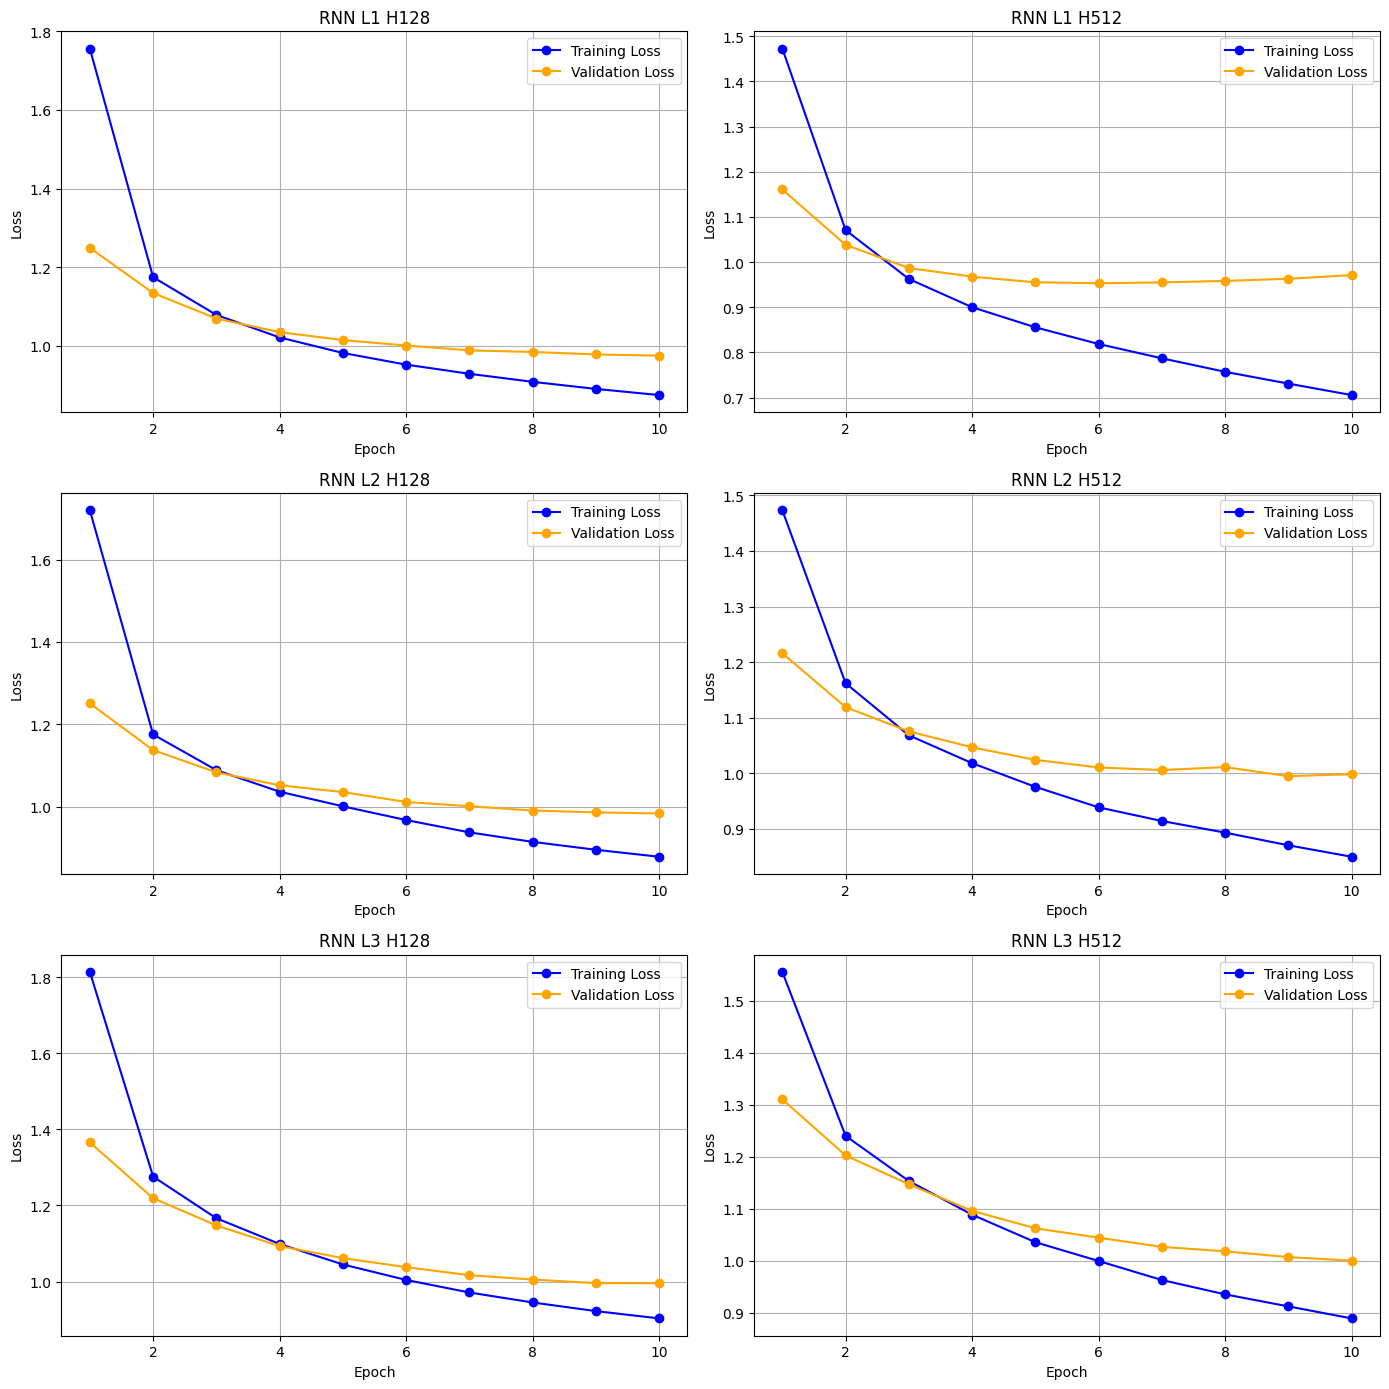

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (name, history) in enumerate(rnn_histories.items()):
    ax = axes[idx]

    ax.plot(
        epochs,
        history["train"],
        color="blue",
        marker="o",
        label="Training Loss"
    )

    ax.plot(
        epochs,
        history["val"],
        color="orange",
        marker="o",
        label="Validation Loss"
    )

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

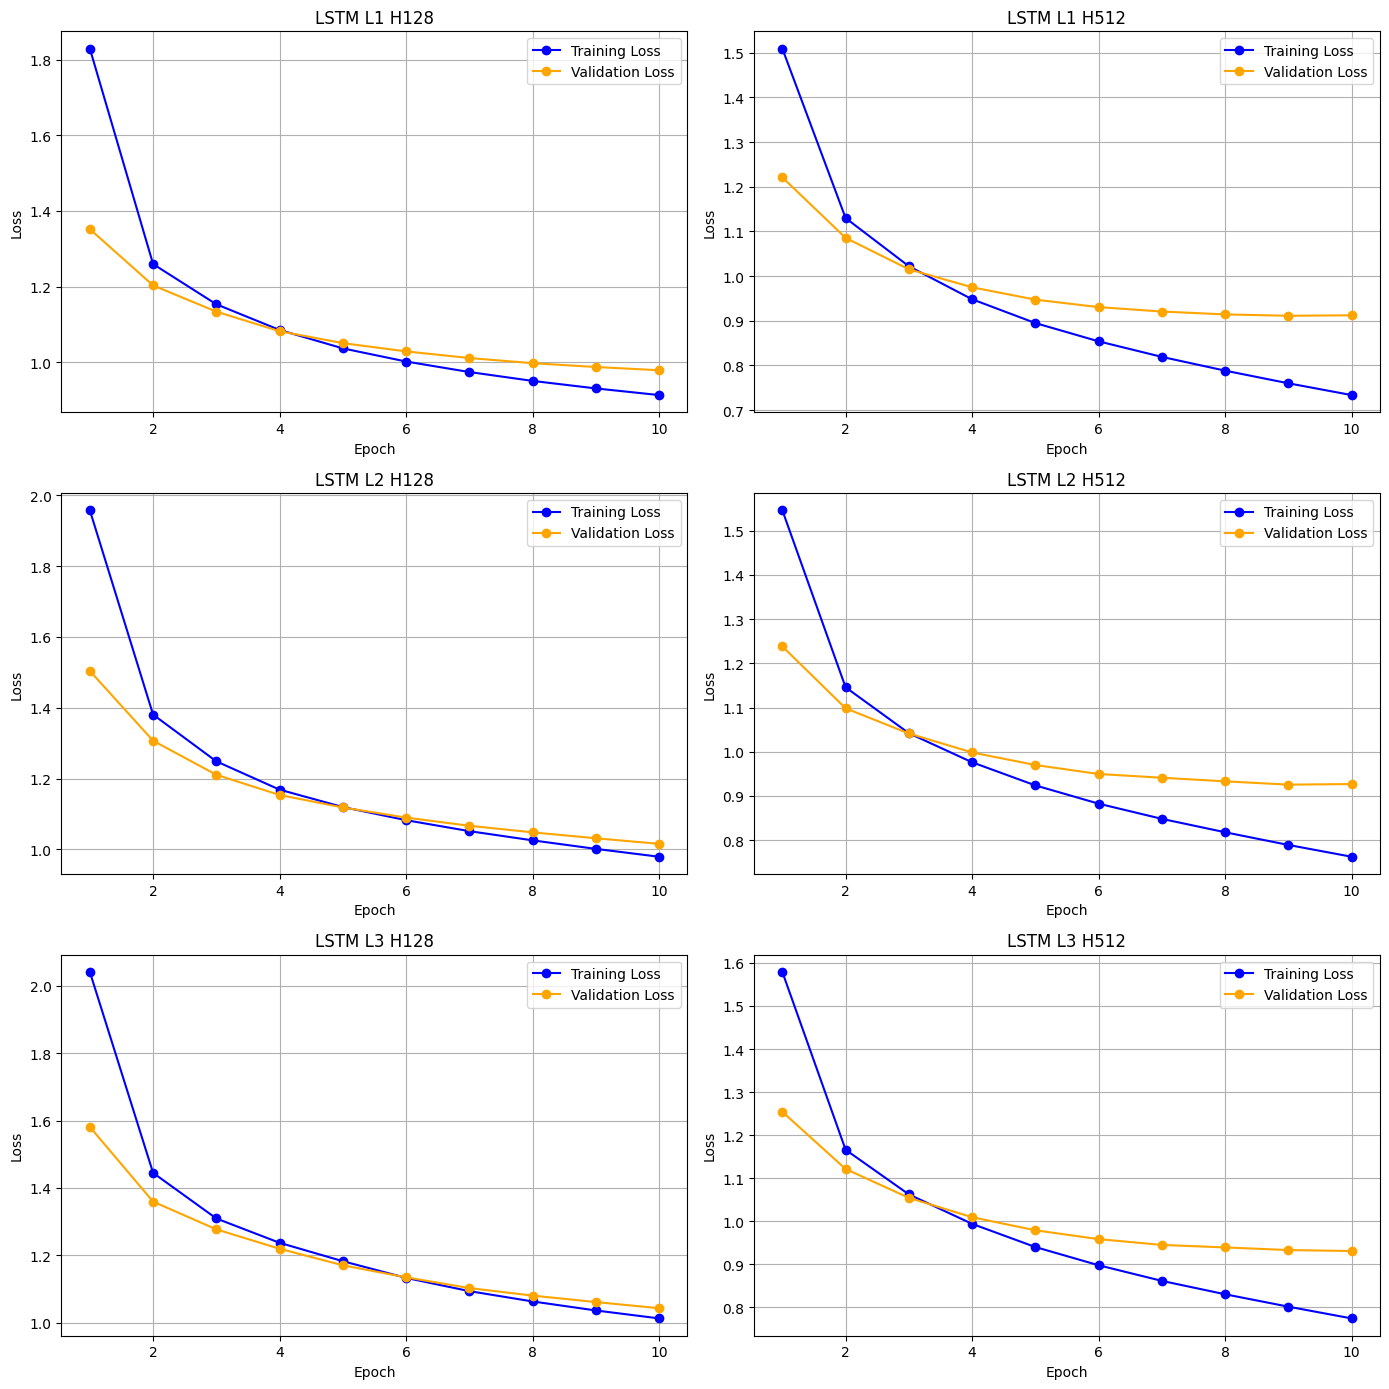

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (name, history) in enumerate(lstm_histories.items()):
    ax = axes[idx]

    ax.plot(
        epochs,
        history["train"],
        color="blue",
        marker="o",
        label="Training Loss"
    )

    ax.plot(
        epochs,
        history["val"],
        color="orange",
        marker="o",
        label="Validation Loss"
    )

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

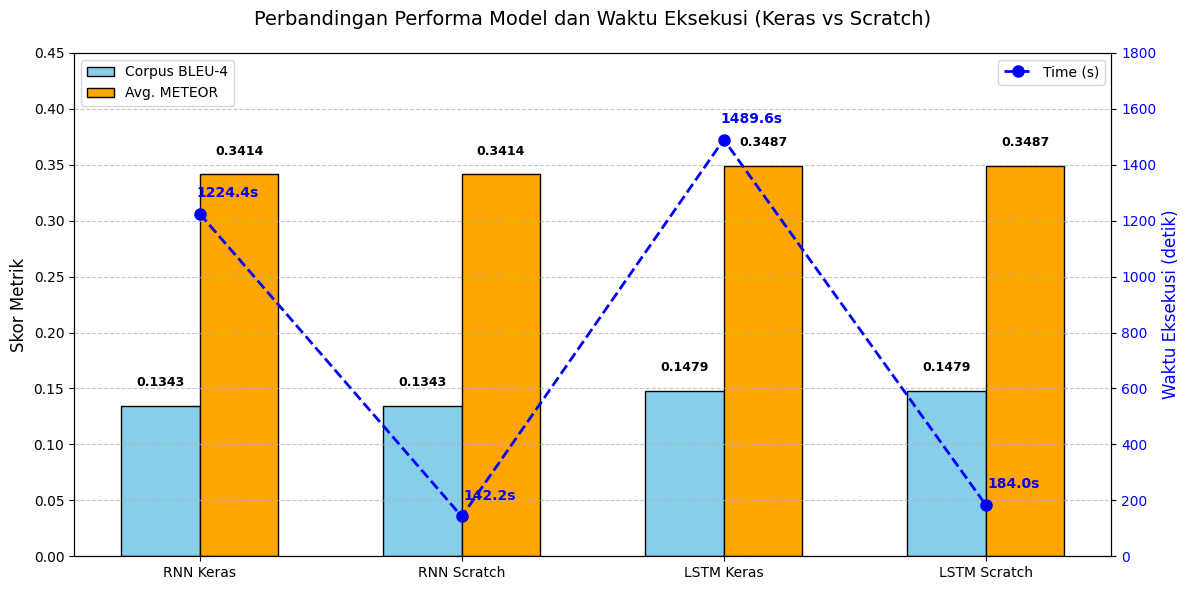

In [191]:
df_sorted_merged = merged_results_df.sort_values(by='Corpus BLEU-4', ascending=True)

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_sorted_merged))
width = 0.3

rects1 = ax1.bar(x - width/2, df_sorted_merged['Corpus BLEU-4'], width, label='Corpus BLEU-4', color='skyblue', edgecolor='black')
rects2 = ax1.bar(x + width/2, df_sorted_merged['Avg. METEOR'], width, label='Avg. METEOR', color='orange', edgecolor='black')

ax1.set_ylabel('Skor Metrik', fontsize=12)
ax1.set_title('Perbandingan Performa Model dan Waktu Eksekusi (Keras vs Scratch)', fontsize=14, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(df_sorted_merged['Model'] + ' ' + df_sorted_merged['Implementation'], fontsize=10)
ax1.set_ylim(0, 0.45)
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(x, df_sorted_merged['Time'], color='blue', marker='o', markersize=8, linestyle='--', linewidth=2, label='Time (s)')
ax2.set_ylabel('Waktu Eksekusi (detik)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 1800)
ax2.legend(loc='upper right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    textcoords="offset points",
                    xytext=(0, 12),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

for i, txt in enumerate(df_sorted_merged['Time']):
    ax2.annotate(f'{txt:.1f}s', (x[i], df_sorted_merged['Time'].iloc[i]),
                 textcoords="offset points", xytext=(20, 12),
                 ha='center', color='blue', weight='bold', fontsize=10)

plt.tight_layout()
plt.show()

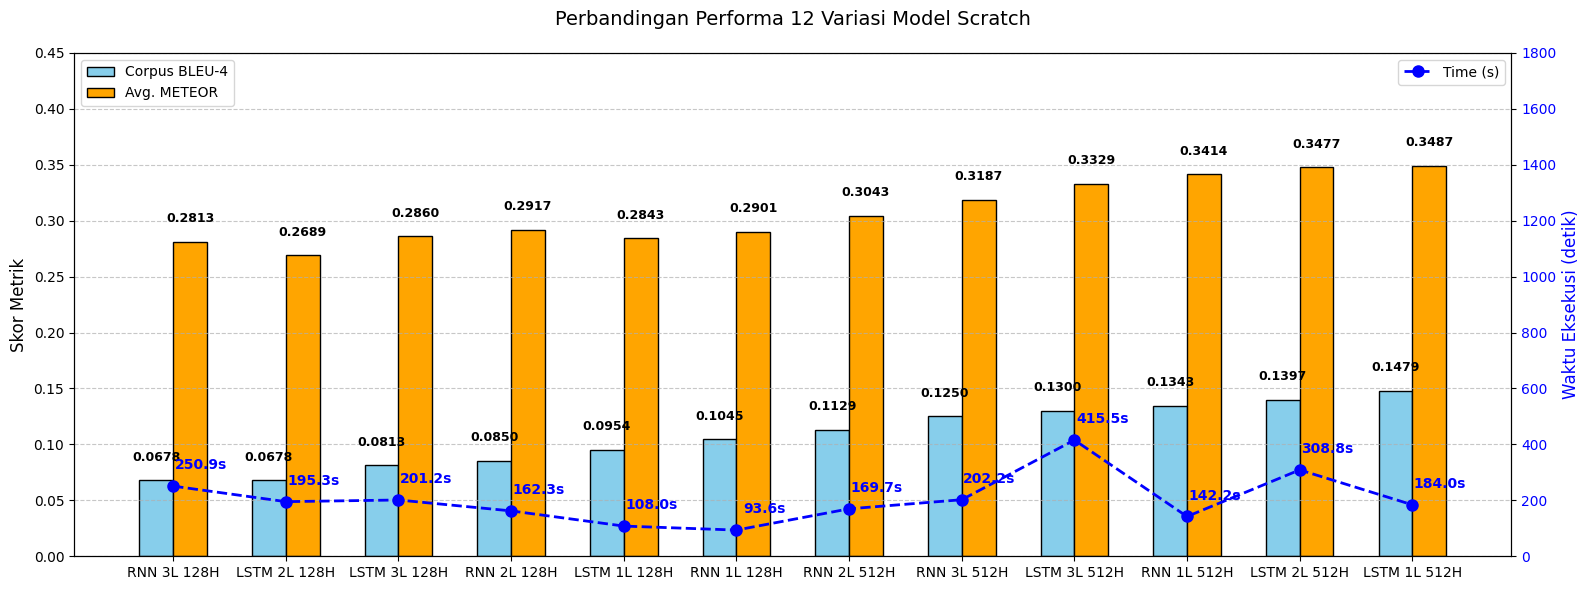

In [213]:
df_sorted_results = df_results.sort_values(by='Corpus BLEU-4', ascending=True)
df_sorted_results['Label'] = df_sorted_results['Model'] + ' ' + df_sorted_results['Layers'].astype(str)+'L '+df_sorted_results['Hidden Size'].astype(str)+'H'

fig, ax1 = plt.subplots(figsize=(16, 6))

x = np.arange(len(df_sorted_results))
width = 0.3

rects1 = ax1.bar(x - width/2, df_sorted_results['Corpus BLEU-4'], width, label='Corpus BLEU-4', color='skyblue', edgecolor='black')
rects2 = ax1.bar(x + width/2, df_sorted_results['Avg. METEOR'], width, label='Avg. METEOR', color='orange', edgecolor='black')

ax1.set_ylabel('Skor Metrik', fontsize=12)
ax1.set_title('Perbandingan Performa 12 Variasi Model Scratch', fontsize=14, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(df_sorted_results['Label'], fontsize=10)
ax1.set_ylim(0, 0.45)
ax1.legend(loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(x, df_sorted_results['Time'], color='blue', marker='o', markersize=8, linestyle='--', linewidth=2, label='Time (s)')
ax2.set_ylabel('Waktu Eksekusi (detik)', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 1800)
ax2.legend(loc='upper right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    textcoords="offset points",
                    xytext=(0, 12),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

for i, txt in enumerate(df_sorted_results['Time']):
    ax2.annotate(f'{txt:.1f}s', (x[i], df_sorted_results['Time'].iloc[i]),
                 textcoords="offset points", xytext=(20, 12),
                 ha='center', color='blue', weight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [175]:
def display_dual_model_comparison(results_rnn, results_lstm, test_image_ids, img_dir, sort_by='RNN'):
    base_results = results_rnn if sort_by == 'RNN' else results_lstm

    sorted_indices = sorted(range(len(base_results)), key=lambda k: base_results[k]['bleu4'], reverse=True)

    total = len(sorted_indices)
    selection = sorted_indices[:3] + sorted_indices[total//2 - 2 : total//2 + 2] + sorted_indices[-3:]

    print(f"\n{'='*60}")
    print(f" ANALISIS KUALITATIF: DIURUTKAN BERDASARKAN SKOR {sort_by} ")
    print(f"{'='*60}\n")

    for i, idx in enumerate(selection):
        if i == 0: print("=====  HIGH  =====")
        if i == 3: print("===== MEDIUM =====")
        if i == 7: print("=====  LOW   =====")
        img_id = test_image_ids[idx]
        img_path = os.path.join(img_dir, f"{img_id}.jpg")

        res_r = results_rnn[idx]
        res_l = results_lstm[idx]

        plt.figure(figsize=(3, 2))
        try:
            img = load_image(img_path, target_size=(199,199))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Sampel {i+1} (Index {idx})")
            plt.show()
        except:
            print(f"[Gambar {img_id} tidak ditemukan]")

        gt = res_r['ground_truth']
        print(f"Ground Truth   : {gt[8:len(gt)-6]}")
        print(f"RNN Prediction : {res_r['prediction']} (BLEU: {res_r['bleu4']:.4f})")
        print(f"LSTM Prediction: {res_l['prediction']} (BLEU: {res_l['bleu4']:.4f})")
        print("-" * 60)

def display_caption_length_comparison(lengths, results, test_image_ids, img_dir):
    base_length = lengths[-1]
    base_length_idx = len(lengths)-1
    sorted_indices = sorted(range(len(results[base_length_idx])), key=lambda k: results[base_length_idx][k]['bleu4'], reverse=True)
    filtered_indices = [idx for idx in sorted_indices if len(results[base_length_idx][idx]['prediction'].split(' ')) > lengths[base_length_idx-1]]

    total = len(filtered_indices)
    selection = filtered_indices[:3] + filtered_indices[total//2 - 2 : total//2 + 2] + filtered_indices[-3:]

    print(f"\n{'='*60}")
    print(f" ANALISIS PENGARUH PANJANG CAPTION (Berdasarkan Skor Panjang {base_length}) ")
    print(f"{'='*60}\n")

    for i, idx in enumerate(selection):
        if i == 0: print("=====  HIGH  =====")
        if i == 3: print("===== MEDIUM =====")
        if i == 7: print("=====  LOW   =====")
        img_id = test_image_ids[idx]
        img_path = os.path.join(img_dir, f"{img_id}.jpg")

        plt.figure(figsize=(3, 2))
        try:
            img = load_image(img_path, target_size=(199,199))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Sampel {i+1} (Index {idx})")
            plt.show()
        except:
            print(f"[Gambar {img_id} tidak ditemukan]")

        gt = results[base_length_idx][idx]['ground_truth']
        print(f"Ground Truth   : {gt[8:len(gt)-6]}")
        for i, length in enumerate(lengths):
            print(f"Max Len {length:2} : {results[i][idx]['prediction']:<60} (BLEU: {results[i][idx]['bleu4']:.4f})")
        print("-" * 60)

In [97]:
rnn_res  = merged_results_df.loc[(merged_results_df['Model']=='RNN')  & (merged_results_df['Implementation']=='Scratch')]['Preds'].item()
lstm_res = merged_results_df.loc[(merged_results_df['Model']=='LSTM') & (merged_results_df['Implementation']=='Scratch')]['Preds'].item()


 ANALISIS KUALITATIF: DIURUTKAN BERDASARKAN SKOR RNN 

=====  HIGH  =====


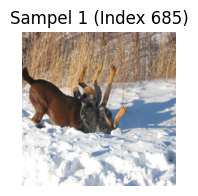

Ground Truth   : a brown dog and a gray dog are playing in the snow
RNN Prediction : two dogs play in the snow (BLEU: 1.0000)
LSTM Prediction: a dog is running through the snow (BLEU: 0.0974)
------------------------------------------------------------


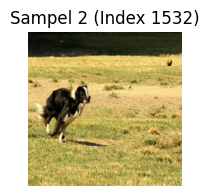

Ground Truth   : a black and white dog is chasing a ball on an open plane
RNN Prediction : a black and white dog is running through a field (BLEU: 0.9622)
LSTM Prediction: a black and white dog is running through a grassy field (BLEU: 0.9147)
------------------------------------------------------------


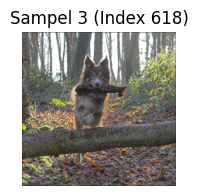

Ground Truth   : a dog is jumping over a log in a wooded area while carrying another log
RNN Prediction : a dog is jumping over a fallen tree (BLEU: 0.9457)
LSTM Prediction: a dog is jumping over a log (BLEU: 0.8669)
------------------------------------------------------------
===== MEDIUM =====


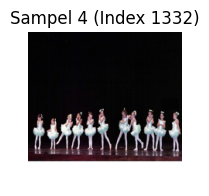

Ground Truth   : a group of little girls perform a recital onstage dressed in all white
RNN Prediction : a large group of people are sitting on a fire (BLEU: 0.0891)
LSTM Prediction: a crowd of people are in a <unk> race (BLEU: 0.0385)
------------------------------------------------------------


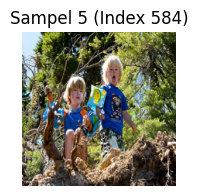

Ground Truth   : there are two kids in swimmies playing outside next to some trees
RNN Prediction : a young girl wearing a pink shirt is standing on a rock in the middle of the water (BLEU: 0.0891)
LSTM Prediction: a young girl is climbing a rock wall (BLEU: 0.0847)
------------------------------------------------------------


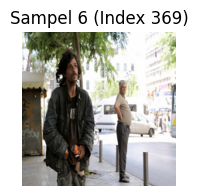

Ground Truth   : a homeless man being observed by a man in business attire
RNN Prediction : a man and woman walk down the street (BLEU: 0.0889)
LSTM Prediction: a man in a black jacket is standing in front of a <unk> (BLEU: 0.1106)
------------------------------------------------------------


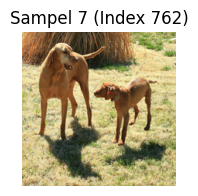

Ground Truth   : a large and small dog interact in a grassy field
RNN Prediction : two dogs are playing together in the grass (BLEU: 0.0889)
LSTM Prediction: a brown dog is running through the grass (BLEU: 0.0748)
------------------------------------------------------------
=====  LOW   =====


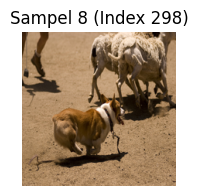

Ground Truth   : a brown and white corgi trailing a leash chasing sheep
RNN Prediction : three dogs are playing together in the grass (BLEU: 0.0000)
LSTM Prediction: a dog is running through a grassy field (BLEU: 0.0847)
------------------------------------------------------------


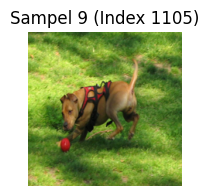

Ground Truth   : a brown dog in a red harness chasing a red ball
RNN Prediction : two dogs are running through the grass (BLEU: 0.0000)
LSTM Prediction: a brown dog is running through the grass (BLEU: 0.1774)
------------------------------------------------------------


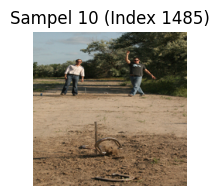

Ground Truth   : two guys are playing horse shoe together
RNN Prediction : a man in a blue shirt is running on the grass (BLEU: 0.0000)
LSTM Prediction: a man in a blue shirt is throwing a ball into a lake (BLEU: 0.0000)
------------------------------------------------------------


In [116]:
display_dual_model_comparison(rnn_res, lstm_res, eval_image_ids, IMAGE_DIR, sort_by='RNN')



 ANALISIS KUALITATIF: DIURUTKAN BERDASARKAN SKOR LSTM 

=====  HIGH  =====


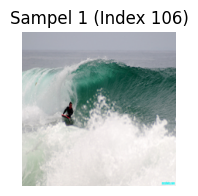

Ground Truth   : a man dressed in black is surfing on a large blue wave
RNN Prediction : a surfer rides a wave (BLEU: 0.4047)
LSTM Prediction: a surfer is riding a wave (BLEU: 1.0000)
------------------------------------------------------------


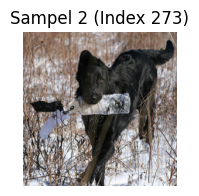

Ground Truth   : a black dog carries a white toy in his mouth and walks on the snowy field
RNN Prediction : a black dog running through the snow (BLEU: 0.5946)
LSTM Prediction: a black dog is running through the snow (BLEU: 1.0000)
------------------------------------------------------------


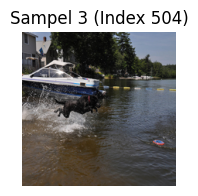

Ground Truth   : a black dog jumping into some water to catch a red and blue frisbee
RNN Prediction : a <unk> <unk> <unk> in the water (BLEU: 0.1159)
LSTM Prediction: a dog is jumping into the water (BLEU: 1.0000)
------------------------------------------------------------
===== MEDIUM =====


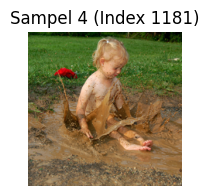

Ground Truth   : a little blonde girl splashing in a mud puddle
RNN Prediction : a young boy wearing a blue shirt is playing in the water (BLEU: 0.0604)
LSTM Prediction: a young girl is playing in the water (BLEU: 0.0940)
------------------------------------------------------------


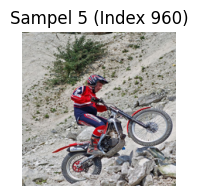

Ground Truth   : a dirt biker rides up a rocky hill on a motorized dirt bike
RNN Prediction : a man is riding a bicycle on a dirt path (BLEU: 0.1891)
LSTM Prediction: a man rides a bicycle down a hill (BLEU: 0.0937)
------------------------------------------------------------


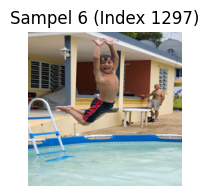

Ground Truth   : a child is jumping into a swimming pool
RNN Prediction : a young boy in a blue shirt is jumping in the air (BLEU: 0.0713)
LSTM Prediction: a young boy is jumping on a trampoline (BLEU: 0.0937)
------------------------------------------------------------


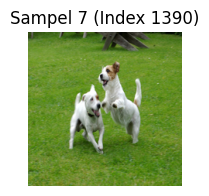

Ground Truth   : two dogs play in the grass
RNN Prediction : two white dogs are running through the grass (BLEU: 0.4111)
LSTM Prediction: two dogs are running through a grassy field (BLEU: 0.0937)
------------------------------------------------------------
=====  LOW   =====


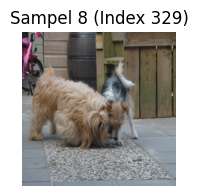

Ground Truth   : the two dogs are interested in the gravel ground surrounded by concrete
RNN Prediction : a small dog is running through the grass (BLEU: 0.0340)
LSTM Prediction: a dog is jumping up a hurdle (BLEU: 0.0000)
------------------------------------------------------------


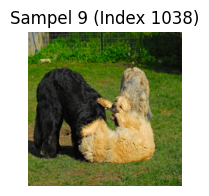

Ground Truth   : the three dogs are playing with each other
RNN Prediction : two dogs are playing in a grassy area (BLEU: 0.1774)
LSTM Prediction: a black dog is biting a smaller dog (BLEU: 0.0000)
------------------------------------------------------------


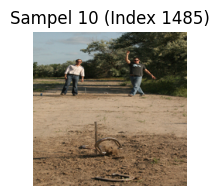

Ground Truth   : two guys are playing horse shoe together
RNN Prediction : a man in a blue shirt is running on the grass (BLEU: 0.0000)
LSTM Prediction: a man in a blue shirt is throwing a ball into a lake (BLEU: 0.0000)
------------------------------------------------------------


In [117]:
display_dual_model_comparison(rnn_res, lstm_res, eval_image_ids, IMAGE_DIR, sort_by='LSTM')

In [147]:
length_res = df_lengths['Preds'].tolist()
lengths = df_lengths['Max Length'].tolist()


 ANALISIS PENGARUH PANJANG CAPTION (Berdasarkan Skor Panjang 40) 

=====  HIGH  =====


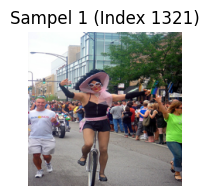

Ground Truth   : a person in a dress and a pink feathered hat rides a unicycle in a parade
Max Len 10 : a man in a red shirt and a woman in                          (BLEU: 0.1268)
Max Len 20 : a man in a red shirt and a woman in a black shirt and a black hat with a bicycle (BLEU: 0.2519)
Max Len 40 : a man in a red shirt and a woman in a black shirt and a black hat with a bicycle in the background (BLEU: 0.2207)
------------------------------------------------------------


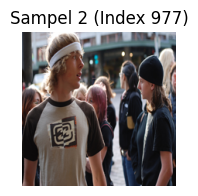

Ground Truth   : a teenage boy with a white headband looking right a crowd in the background
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.3661)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black shirt with a <unk> (BLEU: 0.2031)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black shirt with a <unk> <unk> (BLEU: 0.1927)
------------------------------------------------------------


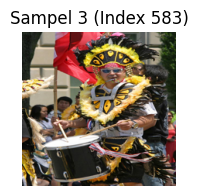

Ground Truth   : a man dressed in an indian costume plays the drums
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.4273)
Max Len 20 : a man in a black shirt and a woman in a white shirt and a white shirt with a <unk> (BLEU: 0.1950)
Max Len 40 : a man in a black shirt and a woman in a white shirt and a white shirt with a <unk> <unk> (BLEU: 0.1849)
------------------------------------------------------------
===== MEDIUM =====


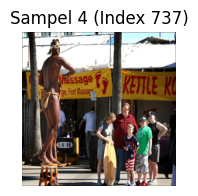

Ground Truth   : a family of five is watching a performer standing on a stepstool
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.2778)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are (BLEU: 0.1326)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are playing a bagpipe (BLEU: 0.1141)
------------------------------------------------------------


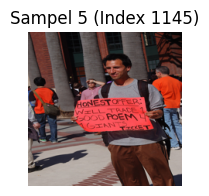

Ground Truth   : a man holding up a red sign that offers the honest trade of a good poem for a giant s ticket
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.3247)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black hat with a <unk> (BLEU: 0.1457)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black hat with a <unk> in a black and white shirt with a <unk> in a black and white shirt (BLEU: 0.0845)
------------------------------------------------------------


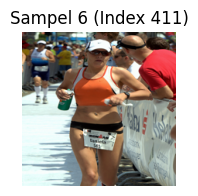

Ground Truth   : a female runner in a race
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.1760)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are (BLEU: 0.0858)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are standing in front of a crowd (BLEU: 0.0661)
------------------------------------------------------------


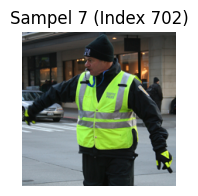

Ground Truth   : a man in a lime green vest directs traffic
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.2907)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black hat with a <unk> (BLEU: 0.1326)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black hat with a <unk> in a black and white shirt and a black and white <unk> are standing in front of a <unk> (BLEU: 0.0653)
------------------------------------------------------------
=====  LOW   =====


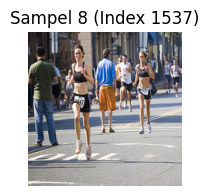

Ground Truth   : a girl in black clothes leads the way in a race
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.0750)
Max Len 20 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are (BLEU: 0.0405)
Max Len 40 : a man in a black shirt and a woman in a black shirt and a black and white <unk> are standing in front of a crowd (BLEU: 0.0330)
------------------------------------------------------------


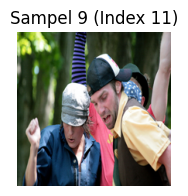

Ground Truth   : a group of people dancing together
Max Len 10 : a man in a black shirt and a man in                          (BLEU: 0.0300)
Max Len 20 : a man in a black shirt and a man in a black shirt and a black shirt with a <unk> (BLEU: 0.0195)
Max Len 40 : a man in a black shirt and a man in a black shirt and a black shirt with a <unk> <unk> in front of a crowd (BLEU: 0.0164)
------------------------------------------------------------


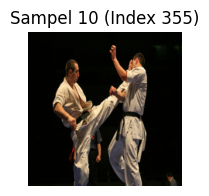

Ground Truth   : a martial artist kicks the face of his opponent
Max Len 10 : a man in a black shirt and a woman in                        (BLEU: 0.0332)
Max Len 20 : a man in a black shirt and a woman in a white shirt and a white shirt with a <unk> (BLEU: 0.0160)
Max Len 40 : a man in a black shirt and a woman in a white shirt and a white shirt with a <unk> <unk> (BLEU: 0.0162)
------------------------------------------------------------


In [176]:
display_caption_length_comparison(lengths, length_res, eval_image_ids, IMAGE_DIR)

In [177]:
merged_results_df.drop(columns=['Preds'])

,Model,Implementation,Corpus BLEU-4,Avg. METEOR,Time
0,RNN,Keras,0.134276,0.341362,1224.417219
1,LSTM,Keras,0.147896,0.348671,1489.628119
7,LSTM,Scratch,0.147896,0.348671,184.040311
1,RNN,Scratch,0.134276,0.341362,142.224885
